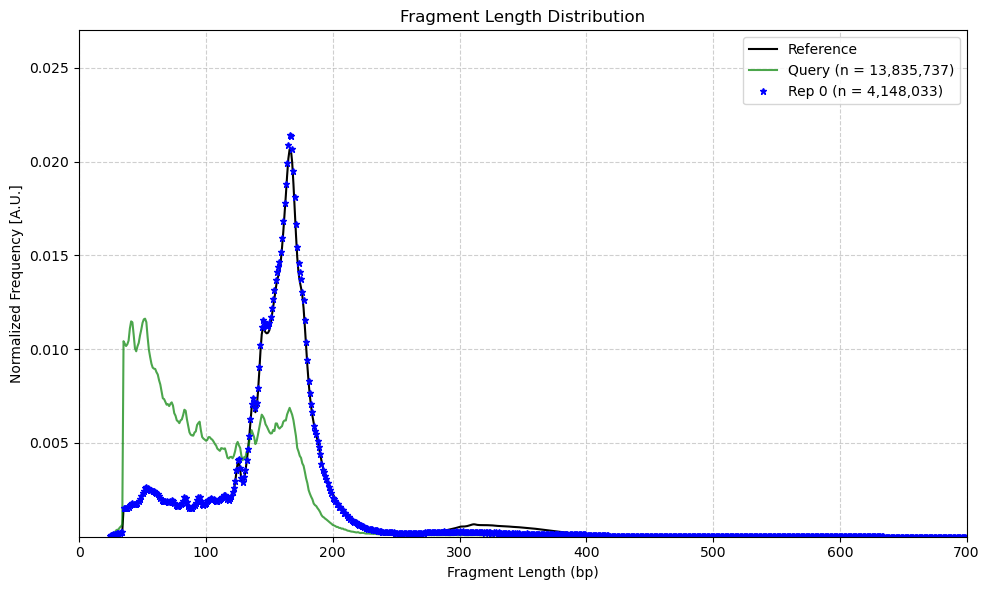

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
import gzip
import numpy as np
import random

fp = "query.bed.gz"
spos, epos = [], []

with gzip.open(fp, 'rt') as f:
    for ln in f:
        p = ln.strip().split()
        if len(p) >= 3:
            s, e = int(p[1]), int(p[2])
            spos.append(s)
            epos.append(e)

lens = [e - s for s, e in zip(spos, epos)]
lc = Counter(lens)
n = sum(lc.values())
nf = {l: c / n for l, c in lc.items()}
sl = sorted(nf.items())
x = [l for l, _ in sl]
y = [f for _, f in sl]

ref = pd.read_csv("reference.hist", sep=r'\s+', header=None, names=["len", "cnt"])
ref_sum = ref["cnt"].sum()
ref["freq"] = ref["cnt"] / ref_sum
rhist = dict(zip(ref["len"], ref["freq"]))

tgt = 4295020
lmap = defaultdict(list)
for i, l in enumerate(lens):
    lmap[l].append(i)

tgt_cnts = {l: int(f * tgt) for l, f in rhist.items()}
idx = []
for l, c in tgt_cnts.items():
    cands = lmap.get(l, [])
    idx.extend(random.sample(cands, c) if len(cands) >= c else cands)

rlen = [lens[i] for i in idx]
rc = Counter(rlen)
rtotal = sum(rc.values())
rf = {l: c / rtotal for l, c in rc.items()}

plt.figure(figsize=(10, 6))
rx = sorted(rhist.keys())
ry = [rhist[k] for k in rx]
plt.plot(rx, ry, label='Reference', color='black', linewidth=1.5)
plt.plot(x, y, label=f'Query (n = {len(lens):,})', color='green', linewidth=1.5, alpha=0.7)
rx2 = sorted(rf.keys())
ry2 = [rf[k] for k in rx2]
plt.plot(rx2, ry2, label=f'Rep 0 (n = {rtotal:,})', color='blue', linestyle='None', marker='*', markersize=5)

plt.xlabel('Fragment Length (bp)')
plt.ylabel('Normalized Frequency [A.U.]')
plt.title('Fragment Length Distribution')
plt.ylim(0, 0.027)
plt.xlim(0, 700)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right')
plt.yticks([0.005, 0.01, 0.015, 0.02, 0.025])
plt.xticks(range(0, 701, 100))
plt.tight_layout()
plt.show()
